In [1]:
!pip install transformers datasets rouge-score sentencepiece -q

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import Dataset
from rouge_score import rouge_scorer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {device}")

  Preparing metadata (setup.py) ... done
  Using device: cuda


In [2]:
from google.colab import files
uploaded = files.upload()  # upload clean_cnn_data.csv

df = pd.read_csv('clean_cnn_data.csv')

# Check how many samples actually have
print(f"Total samples available: {len(df)}")

# Safely sample — use all data if less than 5000
sample_size = min(5000, len(df))
df = df.sample(sample_size, random_state=42).reset_index(drop=True)

print(f"  Using {len(df)} samples")
print(df.head(3))

Saving clean_cnn_data.csv to clean_cnn_data.csv
Total samples available: 4961
  Using 4961 samples
                                             article  \
0  LONDON, England A British woman who suffers fr...   
1  An A380 superjumbo bound for Sydney came loose...   
2  LAS VEGAS, Nevada A jury of nine women and thr...   

                                             summary  
0  UK court rejects appeal calling for clarificat...  
1  Four wheels of A380 superjumbo roll onto grass...  
2  NEW: Prosecutors revealed in court that no bla...  


In [3]:
MODEL_NAME = 'facebook/bart-base'  # smaller BART
print(f"  Loading {MODEL_NAME}...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model     = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
model     = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Model loaded")
print(f"  Trainable parameters: {total_params:,}")

  Loading facebook/bart-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

  Model loaded
  Trainable parameters: 139,420,416


In [4]:
ARTICLE_MAX_LEN = 512
SUMMARY_MAX_LEN = 128

def tokenize_batch(batch):
    # Tokenize articles
    inputs = tokenizer(
        batch['article'],
        max_length=ARTICLE_MAX_LEN,
        truncation=True,
        padding='max_length'
    )

    # Tokenize summaries — new way without as_target_tokenizer
    targets = tokenizer(
        text_target=batch['summary'],   # ← key fix
        max_length=SUMMARY_MAX_LEN,
        truncation=True,
        padding='max_length'
    )

    inputs['labels'] = [
        [-100 if token == tokenizer.pad_token_id else token for token in label]
        for label in targets['input_ids']
    ]

    return inputs

# Convert to HuggingFace Dataset
train_size = int(0.8 * len(df))
train_df   = df.iloc[:train_size]
val_df     = df.iloc[train_size:]

train_dataset = Dataset.from_pandas(train_df[['article', 'summary']])
val_dataset   = Dataset.from_pandas(val_df[['article', 'summary']])

print("  Tokenizing training data...")
train_tokenized = train_dataset.map(tokenize_batch, batched=True, batch_size=32)

print("  Tokenizing validation data...")
val_tokenized = val_dataset.map(tokenize_batch, batched=True, batch_size=32)

print(f"  Train samples : {len(train_tokenized)}")
print(f"  Val samples   : {len(val_tokenized)}")

  Tokenizing training data...


Map:   0%|          | 0/3968 [00:00<?, ? examples/s]

  Tokenizing validation data...


Map:   0%|          | 0/993 [00:00<?, ? examples/s]

  Train samples : 3968
  Val samples   : 993


In [5]:
training_args = Seq2SeqTrainingArguments(
    output_dir                  = './bart_output',
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    logging_dir                 = './logs',
    logging_steps               = 50,
    eval_strategy               = 'epoch',   # ← renamed from evaluation_strategy
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    predict_with_generate       = True,
    fp16                        = True,
    generation_max_length       = SUMMARY_MAX_LEN,
    report_to                   = 'none'
)

print("  Training arguments set")
print(f"   Epochs          : {training_args.num_train_epochs}")
print(f"   Batch size      : {training_args.per_device_train_batch_size}")
print(f"   Mixed precision : {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  Training arguments set
   Epochs          : 3
   Batch size      : 8
   Mixed precision : True


In [6]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    padding=True
)

trainer = Seq2SeqTrainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_tokenized,
    eval_dataset      = val_tokenized,
    processing_class  = tokenizer,    # ← renamed from tokenizer
    data_collator     = data_collator
)

print("Trainer initialized")

Trainer initialized


In [7]:

train_result = trainer.train()

print("\n Training complete!")
print(f"   Total steps    : {train_result.global_step}")
print(f"   Training loss  : {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss
1,2.419879,2.222969
2,2.078101,2.144405
3,1.856578,2.135322


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



 Training complete!
   Total steps    : 1488
   Training loss  : 2.2095


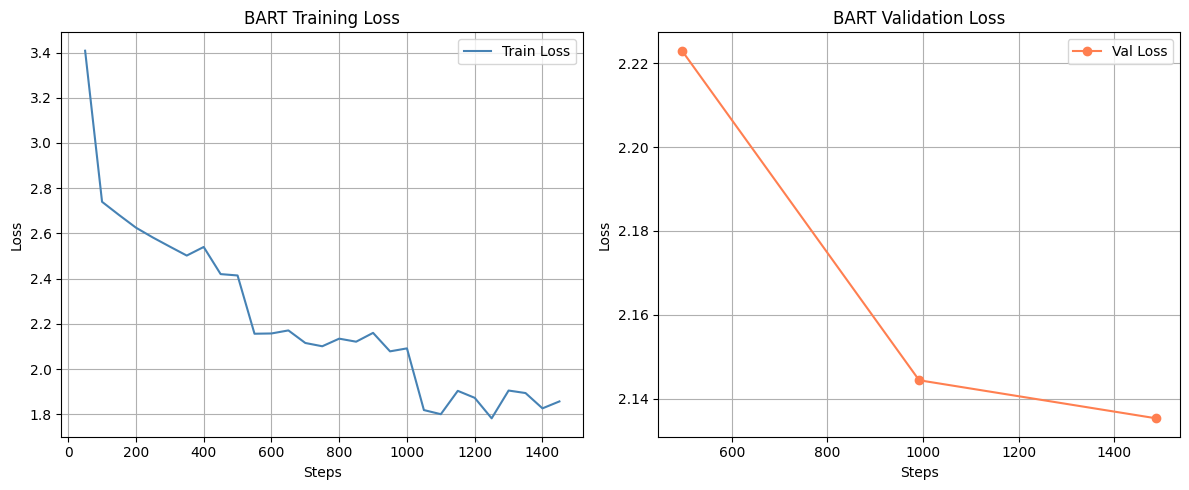

 Saved bart_training_curves.png


In [8]:
# Extract loss logs
logs = trainer.state.log_history

train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in logs if 'eval_loss' in l]

train_steps  = [l['step'] for l in train_logs]
train_losses = [l['loss'] for l in train_logs]

eval_steps   = [l['step'] for l in eval_logs]
eval_losses  = [l['eval_loss'] for l in eval_logs]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_steps, train_losses, color='steelblue', label='Train Loss')
plt.title('BART Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_losses, color='coral', marker='o', label='Val Loss')
plt.title('BART Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('bart_training_curves.png', dpi=150)
plt.show()
print(" Saved bart_training_curves.png")

In [9]:
def generate_summary_bart(article, max_length=128):
    inputs = tokenizer(
        article,
        max_length=ARTICLE_MAX_LEN,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    model.eval()
    with torch.no_grad():
        summary_ids = model.generate(
            inputs['input_ids'],
            num_beams          = 4,     # beam search for better quality
            max_length         = max_length,
            min_length         = 20,
            length_penalty     = 2.0,
            early_stopping     = True,
            no_repeat_ngram_size = 3    # avoid repetition
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# ROUGE scores on 100 validation samples
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
r1, r2, rL = [], [], []

print("  Evaluating on 100 samples...")
for i, row in val_df.iloc[:100].iterrows():
    generated = generate_summary_bart(row['article'])
    reference = row['summary']
    scores    = scorer.score(reference, generated)
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

print("\n  ROUGE SCORES COMPARISON")
print(f"{'Model':<25} {'ROUGE-1':>10} {'ROUGE-2':>10} {'ROUGE-L':>10}")
print("-" * 60)
print(f"{'LSTM (baseline)':<25} {'0.0228':>10} {'0.0012':>10} {'0.0198':>10}")
print(f"{'BART (fine-tuned)':<25} {sum(r1)/len(r1):>10.4f} {sum(r2)/len(r2):>10.4f} {sum(rL)/len(rL):>10.4f}")

# Sample output
print("\n--- Sample Output ---")
sample = val_df.iloc[0]
print(f"ARTICLE   : {sample['article'][:200]}...")
print(f"REFERENCE : {sample['summary']}")
print(f"GENERATED : {generate_summary_bart(sample['article'])}")

  Evaluating on 100 samples...

  ROUGE SCORES COMPARISON
Model                        ROUGE-1    ROUGE-2    ROUGE-L
------------------------------------------------------------
LSTM (baseline)               0.0228     0.0012     0.0198
BART (fine-tuned)             0.3599     0.1446     0.2354

--- Sample Output ---
ARTICLE   : WASHINGTON Computer hackers have embedded software in the United States' electricity grid and other infrastructure that could potentially disrupt service or damage equipment, two former federal offici...
REFERENCE : 2 ex-federal officials say U.S. electrical grid, other infrastructure targeted . Homeland Security doesn't confirm a breach, says no damage caused by one . Expert says this kind of code could be difficult to detect .
GENERATED : Former officials say code in U.S. power grid was discovered in 2006 or 2007 . Security experts say such computer hacking could be the work of a foreign government . Former CIA operative Robert Baer says government likely wou

In [10]:
import os
os.makedirs('bart_model', exist_ok=True)

model.save_pretrained('bart_model')
tokenizer.save_pretrained('bart_model')

print(" Model saved to bart_model/")

# Zip and download
!zip -r bart_model.zip bart_model/
files.download('bart_model.zip')
files.download('bart_training_curves.png')



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model saved to bart_model/
  adding: bart_model/ (stored 0%)
  adding: bart_model/tokenizer.json (deflated 82%)
  adding: bart_model/generation_config.json (deflated 46%)
  adding: bart_model/tokenizer_config.json (deflated 50%)
  adding: bart_model/config.json (deflated 64%)
  adding: bart_model/model.safetensors (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>